In [1]:
import pandas as pd
import numpy as np
import os

In [21]:
def get_image_input(sim_no,output,r):
    import pandas as pd
    import numpy as np
    import os
    sim = 998
    nodes = 9271
    file = f'csv_files1/sim_w_comb_{sim_no}/S_U_PEEQ_COORD_{sim_no}.csv'
    if os.path.isfile(file):
       
        df = pd.read_csv(file)
        df = df.replace('       NoValue', np.nan)
        df.columns = df.columns.str.lstrip()
        x_cord = df['X']
        y_cord = df['Y']
        rho = np.zeros(len(y_cord))
        phi = np.zeros(len(y_cord))
        for i in range((len(x_cord))):
            rho[i] = np.sqrt(x_cord[i]**2 + y_cord[i]**2)
            phi[i] = np.arctan2(y_cord[i], x_cord[i])
        df['R'] = rho
        df['theta'] = phi
        df_data = df[(df['R'] > r-5) & (df['R'] < r+5)]
        df_data = df_data.astype({'PEEQ': float,'S-S11':float, 'S-S22':float, 'S-S33':float, 'S-S12':float})
        data_S11 = df_data['S-S11'].values
        data_S22 = df_data['S-S22'].values
        data_S33 = df_data['S-S33'].values
        data_S12 = df_data['S-S12'].values
        data_X = df_data['X'].values
        data_Y = df_data['Y'].values
        data_r = df_data['R'].values
        data_theta = df_data['theta'].values
        if output == 'sigmax':
            return (data_S11)
        if output == 'sigmay':
            return (data_S12)
        if output == 'sigmaz':
            return (data_S33)
        if output == 'r':
            return(data_r)
        if output == 'theta':
            return(data_theta)
        if output == 'x':
            return(data_X)
        if output == 'y':
            return(data_Y)
        

In [3]:
len1 = 128
len2 = 36

In [4]:
temp_in= []
temp_ex = []
for i in range(1000):
    file = f'csv_files/sim_w_comb_{i}/S_U_PEEQ_COORD_{i}.csv'
    if os.path.isfile(file):
        temp_in.append(i)
    else:
        temp_ex.append(i)
    

In [5]:
def get_xinput(r,len1):
    import numpy as np
    sim_count = len(temp_in)
    a = np.zeros((128,977))
    for i in range(len(temp_in)):
        a[:,i] = get_image_input(temp_in[i],'sigmax',r)
    return a
x_input = get_xinput(500,len)


In [6]:
def get_youtput(r,len2):
    import numpy as np
    sim_count = len(temp_in)
    a = np.zeros((36,977))
    for i in range(len(temp_in)):
        a[:,i] = get_image_input(temp_in[i],'sigmax',r)
    return a
y_output = get_youtput(700,len2)



In [7]:
y_output.shape

(36, 977)

In [8]:
x_input = x_input.reshape(977,128)
y_output = y_output.reshape(977,36)


# Implementing ML model

In [9]:
# Spliting testing and training
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_input, y_output, test_size=0.2, random_state = 42)

In [10]:
x_train.shape

(781, 128)

In [11]:
x_train

array([[-0.0303767 , -0.031069  , -0.0201012 , ..., -0.0325981 ,
        -0.0270963 , -0.0290904 ],
       [-0.0789267 , -0.0850954 , -0.0449623 , ..., -0.0457528 ,
        -0.0513839 , -0.0531255 ],
       [-0.0524734 , -0.0396712 , -0.0239066 , ..., -0.0157698 ,
        -0.0166049 , -0.0187157 ],
       ...,
       [-0.0225618 , -0.0398502 , -0.0500739 , ..., -0.0344407 ,
        -0.0253559 , -0.0454692 ],
       [-0.0456604 , -0.0531916 , -0.0564574 , ..., -0.0358791 ,
        -0.0368701 , -0.00796908],
       [-0.00558791, -0.0219821 , -0.0347609 , ..., -0.0422346 ,
        -0.0468977 , -0.0242525 ]])

In [12]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [13]:
y_train.shape

(781, 36)

In [14]:
import tensorflow as tf
print(tf.__version__)
# Part 2:Building an ANN using keras
#Initializing ANN
ann = tf.keras.models.Sequential()

2.8.0


In [15]:
#Adding the input and first hidden layer, will be adding a dense layer
ann.add(tf.keras.layers.Dense(units = 264,activation = tf.keras.layers.LeakyReLU(alpha=0.01)))
ann.add(tf.keras.layers.Dense(units = 264,activation = tf.keras.layers.LeakyReLU(alpha=0.01)))
ann.add(tf.keras.layers.Dense(units = 128, activation = tf.keras.layers.LeakyReLU(alpha=0.01)))
ann.add(tf.keras.layers.Dense(units = 128, activation = tf.keras.layers.LeakyReLU(alpha=0.01)))
ann.add(tf.keras.layers.Dense(units = 128, activation = tf.keras.layers.LeakyReLU(alpha=0.01)))
ann.add(tf.keras.layers.Dense(units = 64, activation = tf.keras.layers.LeakyReLU(alpha=0.01)))
ann.add(tf.keras.layers.Dense(units = 64, activation = tf.keras.layers.LeakyReLU(alpha=0.01)))
#ann.add(tf.keras.layers.Dense(units = 264,activation = 'ReLU'))
#ann.add(tf.keras.layers.Dense(units = 128, activation = 'ReLU'))
#ann.add(tf.keras.layers.Dense(units = 64, activation = 'ReLU'))

#ann.add(tf.keras.layers.Dense(units = 32, activation = tf.keras.layers.LeakyReLU(alpha=0.01)))

In [16]:
#Output Layer
ann.add(tf.keras.layers.Dense(units = 36, activation = 'linear'))

In [17]:
#compling ann
ann.compile(optimizer = 'adam', loss = 'mean_squared_error',metrics = ['MeanAbsoluteError'])

In [19]:
#traing the model
# ann.fit(x_train,y_train,batch_size = 32, epochs = 50)
ann.fit(x_train,y_train,batch_size = 32, epochs = 1000)

Epoch 1/1000
25/25 [==============================] - 0s 3ms/step - loss: 8.0513e-05 - mean_absolute_error: 0.0066
Epoch 2/1000
25/25 [==============================] - 0s 3ms/step - loss: 7.8058e-05 - mean_absolute_error: 0.0065
Epoch 3/1000
25/25 [==============================] - 0s 3ms/step - loss: 8.3871e-05 - mean_absolute_error: 0.0068
Epoch 4/1000
25/25 [==============================] - 0s 3ms/step - loss: 8.0260e-05 - mean_absolute_error: 0.0066
Epoch 5/1000
25/25 [==============================] - 0s 3ms/step - loss: 7.6502e-05 - mean_absolute_error: 0.0064
Epoch 6/1000
25/25 [==============================] - 0s 3ms/step - loss: 8.1197e-05 - mean_absolute_error: 0.0067
Epoch 7/1000
25/25 [==============================] - 0s 3ms/step - loss: 7.8801e-05 - mean_absolute_error: 0.0065
Epoch 8/1000
25/25 [==============================] - 0s 3ms/step - loss: 7.3748e-05 - mean_absolute_error: 0.0063
Epoch 9/1000
25/25 [==============================] - 0s 3ms/step - loss: 7.2239

25/25 [==============================] - 0s 3ms/step - loss: 6.6278e-05 - mean_absolute_error: 0.0059
Epoch 72/1000
25/25 [==============================] - 0s 3ms/step - loss: 6.3971e-05 - mean_absolute_error: 0.0058
Epoch 73/1000
25/25 [==============================] - 0s 3ms/step - loss: 6.6161e-05 - mean_absolute_error: 0.0059
Epoch 74/1000
25/25 [==============================] - 0s 3ms/step - loss: 6.5556e-05 - mean_absolute_error: 0.0058
Epoch 75/1000
25/25 [==============================] - 0s 3ms/step - loss: 6.1441e-05 - mean_absolute_error: 0.0057
Epoch 76/1000
25/25 [==============================] - 0s 3ms/step - loss: 6.1452e-05 - mean_absolute_error: 0.0056
Epoch 77/1000
25/25 [==============================] - 0s 3ms/step - loss: 5.8157e-05 - mean_absolute_error: 0.0054
Epoch 78/1000
25/25 [==============================] - 0s 3ms/step - loss: 6.3696e-05 - mean_absolute_error: 0.0058
Epoch 79/1000
25/25 [==============================] - 0s 3ms/step - loss: 6.6273e-05 

25/25 [==============================] - 0s 3ms/step - loss: 5.0949e-05 - mean_absolute_error: 0.0050
Epoch 142/1000
25/25 [==============================] - 0s 3ms/step - loss: 5.6590e-05 - mean_absolute_error: 0.0053
Epoch 143/1000
25/25 [==============================] - 0s 3ms/step - loss: 5.7720e-05 - mean_absolute_error: 0.0054
Epoch 144/1000
25/25 [==============================] - 0s 3ms/step - loss: 4.9495e-05 - mean_absolute_error: 0.0050
Epoch 145/1000
25/25 [==============================] - 0s 3ms/step - loss: 5.6444e-05 - mean_absolute_error: 0.0053
Epoch 146/1000
25/25 [==============================] - 0s 3ms/step - loss: 5.8321e-05 - mean_absolute_error: 0.0054
Epoch 147/1000
25/25 [==============================] - 0s 3ms/step - loss: 5.2425e-05 - mean_absolute_error: 0.0051
Epoch 148/1000
25/25 [==============================] - 0s 3ms/step - loss: 5.2404e-05 - mean_absolute_error: 0.0052
Epoch 149/1000
25/25 [==============================] - 0s 3ms/step - loss: 4.9

25/25 [==============================] - 0s 3ms/step - loss: 4.8063e-05 - mean_absolute_error: 0.0049
Epoch 212/1000
25/25 [==============================] - 0s 3ms/step - loss: 5.0322e-05 - mean_absolute_error: 0.0051
Epoch 213/1000
25/25 [==============================] - 0s 3ms/step - loss: 4.9615e-05 - mean_absolute_error: 0.0050
Epoch 214/1000
25/25 [==============================] - 0s 3ms/step - loss: 4.5279e-05 - mean_absolute_error: 0.0048
Epoch 215/1000
25/25 [==============================] - 0s 3ms/step - loss: 4.9492e-05 - mean_absolute_error: 0.0049
Epoch 216/1000
25/25 [==============================] - 0s 3ms/step - loss: 4.6616e-05 - mean_absolute_error: 0.0048
Epoch 217/1000
25/25 [==============================] - 0s 3ms/step - loss: 6.3095e-05 - mean_absolute_error: 0.0056
Epoch 218/1000
25/25 [==============================] - 0s 3ms/step - loss: 6.2654e-05 - mean_absolute_error: 0.0056
Epoch 219/1000
25/25 [==============================] - 0s 3ms/step - loss: 5.9

25/25 [==============================] - 0s 3ms/step - loss: 3.6168e-05 - mean_absolute_error: 0.0042
Epoch 282/1000
25/25 [==============================] - 0s 3ms/step - loss: 3.7394e-05 - mean_absolute_error: 0.0043
Epoch 283/1000
25/25 [==============================] - 0s 3ms/step - loss: 4.3048e-05 - mean_absolute_error: 0.0045
Epoch 284/1000
25/25 [==============================] - 0s 3ms/step - loss: 4.4031e-05 - mean_absolute_error: 0.0046
Epoch 285/1000
25/25 [==============================] - 0s 3ms/step - loss: 4.2997e-05 - mean_absolute_error: 0.0046
Epoch 286/1000
25/25 [==============================] - 0s 3ms/step - loss: 3.6453e-05 - mean_absolute_error: 0.0042
Epoch 287/1000
25/25 [==============================] - 0s 3ms/step - loss: 3.6110e-05 - mean_absolute_error: 0.0042
Epoch 288/1000
25/25 [==============================] - 0s 3ms/step - loss: 3.4615e-05 - mean_absolute_error: 0.0041
Epoch 289/1000
25/25 [==============================] - 0s 3ms/step - loss: 3.4

...

25/25 [==============================] - 0s 3ms/step - loss: 1.8975e-05 - mean_absolute_error: 0.0030
Epoch 702/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.2776e-05 - mean_absolute_error: 0.0032
Epoch 703/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.8240e-05 - mean_absolute_error: 0.0036
Epoch 704/1000
25/25 [==============================] - 0s 3ms/step - loss: 3.1191e-05 - mean_absolute_error: 0.0038
Epoch 705/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.5198e-05 - mean_absolute_error: 0.0036
Epoch 706/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.2002e-05 - mean_absolute_error: 0.0033
Epoch 707/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.9308e-05 - mean_absolute_error: 0.0031
Epoch 708/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.8626e-05 - mean_absolute_error: 0.0030
Epoch 709/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.2

25/25 [==============================] - 0s 3ms/step - loss: 2.5759e-05 - mean_absolute_error: 0.0036
Epoch 772/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.4048e-05 - mean_absolute_error: 0.0035
Epoch 773/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.5245e-05 - mean_absolute_error: 0.0036
Epoch 774/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.5375e-05 - mean_absolute_error: 0.0036
Epoch 775/1000
25/25 [==============================] - 0s 3ms/step - loss: 3.2783e-05 - mean_absolute_error: 0.0039
Epoch 776/1000
25/25 [==============================] - 0s 3ms/step - loss: 3.2738e-05 - mean_absolute_error: 0.0040
Epoch 777/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.9556e-05 - mean_absolute_error: 0.0038
Epoch 778/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.2074e-05 - mean_absolute_error: 0.0034
Epoch 779/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.0

25/25 [==============================] - 0s 3ms/step - loss: 3.4362e-05 - mean_absolute_error: 0.0039
Epoch 842/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.5888e-05 - mean_absolute_error: 0.0036
Epoch 843/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.2472e-05 - mean_absolute_error: 0.0033
Epoch 844/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.8403e-05 - mean_absolute_error: 0.0031
Epoch 845/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.8425e-05 - mean_absolute_error: 0.0030
Epoch 846/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.5550e-05 - mean_absolute_error: 0.0028
Epoch 847/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.4093e-05 - mean_absolute_error: 0.0027
Epoch 848/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.4116e-05 - mean_absolute_error: 0.0027
Epoch 849/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.4

25/25 [==============================] - 0s 3ms/step - loss: 2.8965e-05 - mean_absolute_error: 0.0036
Epoch 912/1000
25/25 [==============================] - 0s 3ms/step - loss: 3.0931e-05 - mean_absolute_error: 0.0038
Epoch 913/1000
25/25 [==============================] - 0s 3ms/step - loss: 4.5342e-05 - mean_absolute_error: 0.0045
Epoch 914/1000
25/25 [==============================] - 0s 3ms/step - loss: 5.1328e-05 - mean_absolute_error: 0.0051
Epoch 915/1000
25/25 [==============================] - 0s 3ms/step - loss: 3.7470e-05 - mean_absolute_error: 0.0045
Epoch 916/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.8918e-05 - mean_absolute_error: 0.0040
Epoch 917/1000
25/25 [==============================] - 0s 3ms/step - loss: 2.3367e-05 - mean_absolute_error: 0.0036
Epoch 918/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.9716e-05 - mean_absolute_error: 0.0033
Epoch 919/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.6

25/25 [==============================] - 0s 3ms/step - loss: 1.1416e-05 - mean_absolute_error: 0.0023
Epoch 982/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.3779e-05 - mean_absolute_error: 0.0027
Epoch 983/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.3662e-05 - mean_absolute_error: 0.0027
Epoch 984/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.3665e-05 - mean_absolute_error: 0.0027
Epoch 985/1000
25/25 [==============================] - 0s 4ms/step - loss: 1.3188e-05 - mean_absolute_error: 0.0027
Epoch 986/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.4345e-05 - mean_absolute_error: 0.0027
Epoch 987/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.3684e-05 - mean_absolute_error: 0.0027
Epoch 988/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.2997e-05 - mean_absolute_error: 0.0026
Epoch 989/1000
25/25 [==============================] - 0s 3ms/step - loss: 1.2

In [55]:
case = [16,134,198,312,401,632,708,795,866,987]
sigma_x = np.zeros((36,len(case)))
x1 = np.zeros((36,len(case)))
y1 = np.zeros((36,len(case)))
theta = np.zeros((128,len(case)))
for i in range(len(case)):
    sigma_x[:,i] = get_image_input(case[i],'sigmax',700)
    x1[:,i] = get_image_input(case[i],'x',700)
    y1[:,i] = get_image_input(case[i],'y',700)
    theta[:,i] = get_image_input(case[i],'theta',500)

In [56]:
theta.shape
x1[:,5]

array([-700.608 ,    0.    ,    0.    ,  700.608 , -699.866 , -695.7   ,
       -598.516 , -528.211 , -699.949 , -695.47  , -562.905 , -653.144 ,
       -625.73  , -278.719 ,  -56.7729, -113.363 , -370.559 ,  -56.5003,
       -112.609 , -250.534 ,  277.57  ,   56.5152,  112.641 ,   56.779 ,
        113.314 ,  413.611 ,  344.739 ,  699.948 ,  695.477 ,  595.105 ,
        657.669 ,  699.865 ,  695.695 ,  598.35  ,  605.861 ,  656.424 ])

In [57]:
theta = theta.reshape(10,128)
prediction = ann.predict(sc.transform(theta))


In [67]:
x1 = x1.reshape(10,36)
y1 = y1.reshape(10,36)
sigma_x = sigma_x.reshape(10,36)
sigma_x.shape

(10, 36)

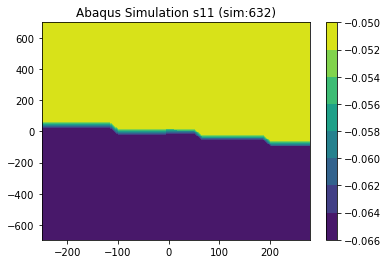

In [68]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

x = np.asarray(x1[5,:])
y = np.asarray(y1[5,:])
z = np.asarray(sigma_x[5,:])
xi = np.linspace(np.min(x), np.max(x), len(x))
yi = np.linspace(np.min(y), np.max(y), len(y))
X,Y= np.meshgrid(xi,yi)
Z = griddata((x, y), z, (X, Y),method='nearest')
plt.contourf(X,Y,Z)
plt.title("Abaqus Simulation s11 (sim:632)")
plt.colorbar()

In [70]:
df_sim = pd.DataFrame({'X':x, "Y": y, "Z": z})
df_sim

,X,Y,Z
0,-112.6090,-695.521,-0.065908
1,-112.6090,-695.521,-0.078560
2,-112.6090,-695.521,-0.051732
3,-112.6090,-695.521,-0.073978
4,-112.6090,-695.521,-0.074462
5,-112.6090,-695.521,-0.074842
6,-112.6090,-695.521,-0.039752
7,-112.6090,-695.521,-0.074320
8,-112.6090,-695.521,-0.047712
9,-112.6090,-695.521,-0.042198


In [41]:
sigma_x[5]

array([-0.017054 , -0.0354863, -0.032994 , -0.0441137, -0.0215583,
       -0.0309463, -0.0316366, -0.019356 , -0.0397812, -0.0429975])

In [40]:
prediction[5]

array([-0.43447077,  0.6368059 , -1.5587724 , -0.5818151 , -0.7055187 ,
        0.42194262,  0.37969846, -1.6393516 ,  0.3648605 , -0.8505028 ,
        0.20687075, -0.6483099 ,  0.69991225,  0.20633942, -0.24039166,
        0.64918363, -1.0795764 ,  0.32732397, -1.1173398 , -0.9575159 ,
       -0.4368821 , -0.54635084,  0.216438  , -1.210358  , -0.24472716,
       -0.9580316 ,  0.02467185, -1.0739775 , -0.1253589 , -0.5182115 ,
       -0.21265131, -0.01892877,  0.8034984 ,  0.6581625 ,  1.027523  ,
        0.409846  ], dtype=float32)

In [39]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

x = np.asarray(x1[5])
y = np.asarray(y1[5])
z = np.asarray(prediction[5])
z_ml = z
xi = np.linspace(np.min(x), np.max(x), len(x))
yi = np.linspace(np.min(y), np.max(y), len(y))

X,Y= np.meshgrid(xi,yi)
Z = griddata((x, y), z, (X, Y),method='nearest')
plt.contourf(X,Y,Z)
plt.title("Abaqus Simulation s11 (sim:632)")
plt.colorbar()

ValueError: different number of values and points

In [38]:
df_sim = pd.DataFrame({'X': x, "Y":y , "Z":z_ml })

NameError: name 'z_ml' is not defined

In [27]:
sigma_x[5]

array([-0.0659076, -0.07856  , -0.0517322, -0.0739775, -0.0744624,
       -0.074842 , -0.0397518, -0.0743199, -0.0477121, -0.0421979,
       -0.0641101, -0.0722828, -0.046643 , -0.0676413, -0.072815 ,
       -0.0702754, -0.0351273, -0.0806302, -0.0443472, -0.0392249,
       -0.0507551, -0.0582944, -0.0374221, -0.0524645, -0.0570748,
       -0.057196 , -0.0280264, -0.0367867, -0.0349735, -0.0302512,
       -0.0519061, -0.0654528, -0.0431738, -0.0592476, -0.0572345,
       -0.0624604])

In [28]:
prediction[5]

array([-0.43447077,  0.6368059 , -1.5587724 , -0.5818151 , -0.7055187 ,
        0.42194262,  0.37969846, -1.6393516 ,  0.3648605 , -0.8505028 ,
        0.20687075, -0.6483099 ,  0.69991225,  0.20633942, -0.24039166,
        0.64918363, -1.0795764 ,  0.32732397, -1.1173398 , -0.9575159 ,
       -0.4368821 , -0.54635084,  0.216438  , -1.210358  , -0.24472716,
       -0.9580316 ,  0.02467185, -1.0739775 , -0.1253589 , -0.5182115 ,
       -0.21265131, -0.01892877,  0.8034984 ,  0.6581625 ,  1.027523  ,
        0.409846  ], dtype=float32)